# Decision Trees

---

## Introduction

**Decision Trees** are a nonparametric supervised learning method used for classification. Like the Regression Tree, they work by asking a series of yes/no questions about the features and following branches based on the answers. The difference is what the tree predicts at the end:

- **Regression Tree leaf** → predicts the mean of all values in that group
- **Decision Tree leaf** → predicts the **majority class label** of all samples in that group

A Decision Tree is made of three types of nodes:
- **Root node** — the very first question asked at the top of the tree
- **Decision nodes** — internal nodes that ask a question and branch left or right
- **Leaf nodes** — where the final prediction is made

At each split, the tree finds the feature and threshold that creates the **purest** groups — where most samples share the same class label.

In this notebook we use a Decision Tree to answer:

> *Can we predict the type of forest cover in Roosevelt National Forest based on cartographic measurements?*

**Dataset:** Forest Cover Type — Roosevelt National Forest, Colorado  
**Source:** UCI Machine Learning Repository  
**Features:** elevation, aspect, slope, distance to hydrology, roadways, hillshade, fire points  
**Target:** forest cover type (7 classes)

In [5]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom DecisionTreeClassifier from the package ───────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.decision_tree import DecisionTreeClassifier

# ── Sklearn utilities (for preprocessing and evaluation only) ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [6]:
# Load the dataset
df = pd.read_csv('data/Forest_Cover.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (581012, 55)



,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Step 1 — Understanding the Data

We are working with the Forest Cover Type dataset compiled from US Geological Survey and US Forest Service data. It describes wilderness areas in Roosevelt National Forest — areas minimally disturbed by humans, making them ideal for studying natural forest ecosystems.

### Why this dataset?

Predicting forest cover type from map-based variables saves time and resources compared to sending teams into the field. A well-trained model can predict tree species from satellite and topographic data alone.

### Why a Decision Tree?

Decision Trees handle multi-class classification naturally and are easy to interpret — you can trace exactly which questions led to a prediction. They also require no scaling and make no assumptions about the data distribution.

In [7]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Typ

In [8]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

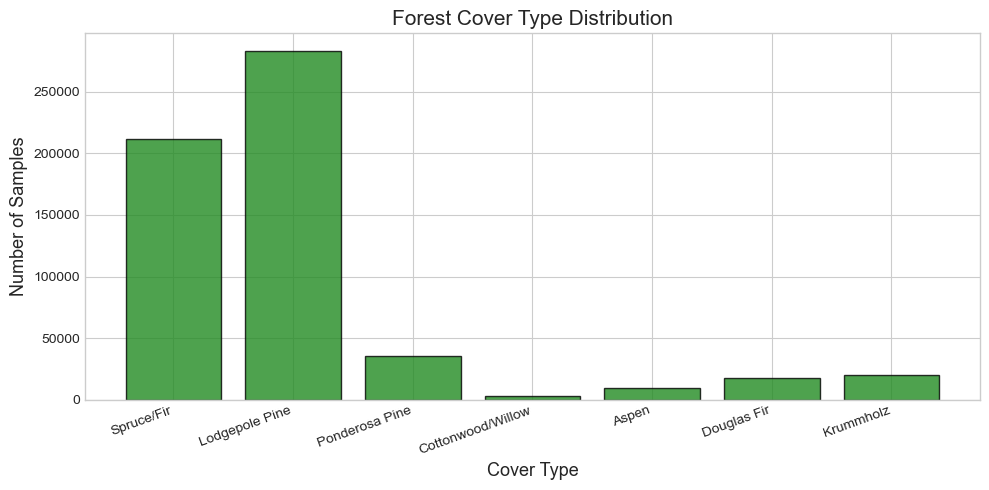

In [9]:
cover_type_names = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas Fir',
    7: 'Krummholz'
}

plt.figure(figsize=(10, 5))
counts = df['Cover_Type'].value_counts().sort_index()
plt.bar([cover_type_names[i] for i in counts.index], counts.values,
        color='forestgreen', edgecolor='black', alpha=0.8)
plt.xlabel('Cover Type', fontsize=13)
plt.ylabel('Number of Samples', fontsize=13)
plt.title('Forest Cover Type Distribution', fontsize=15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Step 2 — The Effect of Max Depth

The most important hyperparameter for a decision tree is `max_depth` — the maximum number of questions the tree is allowed to ask before making a prediction.

- **Shallow tree** — asks few questions, makes simple predictions. May underfit.
- **Deep tree** — asks many questions, fits training data very closely. May overfit.

Overfitting is the biggest risk — a deep enough tree can memorize the entire training set (100% training accuracy) while performing poorly on new data.

## Step 3 — Preprocessing

In [10]:
# Sample to 3000 rows — our pure-Python tree is slow on the full 581k dataset
df_sample = df.sample(n=3000, random_state=42)

feature_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

X = df_sample[feature_cols].to_numpy()
y = df_sample['Cover_Type'].to_numpy()

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Note: decision trees don't require scaling but we apply it for consistency
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')

Training set: 2400 samples
Test set:     600 samples


## Step 4 — Training and Evaluation

In [11]:
# Compare performance across different max_depth values
depths = [1, 2, 3, 5, 7, 10]
train_accs = []
test_accs  = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth)
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train))
    test_accs.append(tree.score(X_test, y_test))
    print(f'max_depth={depth:2d}  |  train acc = {train_accs[-1]*100:.1f}%  |  test acc = {test_accs[-1]*100:.1f}%')

max_depth= 1  |  train acc = 64.1%  |  test acc = 63.2%
max_depth= 2  |  train acc = 68.0%  |  test acc = 67.2%
max_depth= 3  |  train acc = 68.8%  |  test acc = 67.2%
max_depth= 5  |  train acc = 72.3%  |  test acc = 64.5%
max_depth= 7  |  train acc = 79.1%  |  test acc = 64.8%
max_depth=10  |  train acc = 89.2%  |  test acc = 67.3%


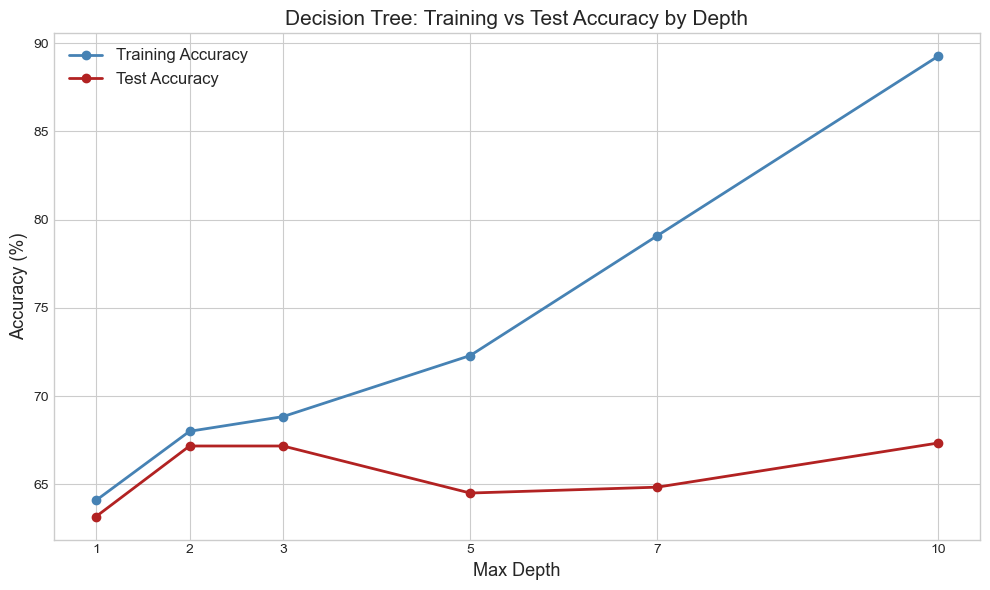

The growing gap between training and test accuracy is overfitting!


In [12]:
# Plot train vs test accuracy — watch the overfitting gap grow
plt.figure(figsize=(10, 6))
plt.plot(depths, [a*100 for a in train_accs], marker='o', color='steelblue',
         linewidth=2, label='Training Accuracy')
plt.plot(depths, [a*100 for a in test_accs], marker='o', color='firebrick',
         linewidth=2, label='Test Accuracy')
plt.xlabel('Max Depth', fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('Decision Tree: Training vs Test Accuracy by Depth', fontsize=15)
plt.legend(fontsize=12)
plt.xticks(depths)
plt.tight_layout()
plt.show()

print('The growing gap between training and test accuracy is overfitting!')

In [13]:
# Train final model with the best depth
best_depth = depths[np.argmax(test_accs)]
print(f'Best max_depth = {best_depth}')

model = DecisionTreeClassifier(max_depth=best_depth)
model.fit(X_train, y_train)

print(f'Training Accuracy: {model.score(X_train, y_train)*100:.2f}%')
print(f'Test Accuracy:     {model.score(X_test, y_test)*100:.2f}%')

Best max_depth = 10
Training Accuracy: 89.25%
Test Accuracy:     67.33%


In [14]:
# Full classification report
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=[cover_type_names[i] for i in sorted(cover_type_names)]
))

Classification Report:
                   precision    recall  f1-score   support

       Spruce/Fir       0.71      0.69      0.70       217
   Lodgepole Pine       0.74      0.75      0.74       297
   Ponderosa Pine       0.40      0.52      0.45        33
Cottonwood/Willow       1.00      0.25      0.40         4
            Aspen       0.33      0.19      0.24        16
      Douglas Fir       0.32      0.30      0.31        20
        Krummholz       0.28      0.38      0.32        13

         accuracy                           0.67       600
        macro avg       0.54      0.44      0.45       600
     weighted avg       0.68      0.67      0.67       600



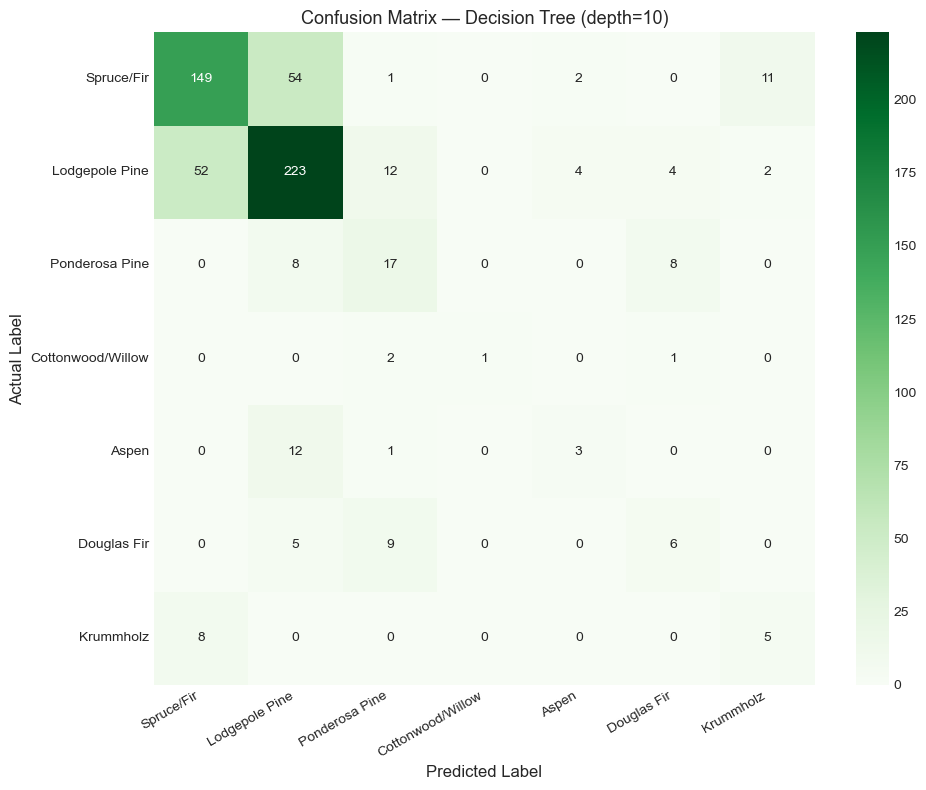

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = [cover_type_names[i] for i in sorted(cover_type_names)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title(f'Confusion Matrix — Decision Tree (depth={best_depth})', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Step 5 — Conclusion

### What did we find?

Our Decision Tree was trained to predict forest cover type from 10 cartographic features. The depth experiment clearly shows the bias-variance tradeoff — as depth increases, training accuracy rises but test accuracy eventually drops due to overfitting.

### Advantages of Decision Trees

1. **Interpretable** — you can trace exactly which questions led to any prediction
2. **No scaling required** — uses thresholds, not distances
3. **Handles non-linear boundaries** naturally
4. **Fast at prediction time** — just traverse the tree

### Limitations

1. **Prone to overfitting** — deep trees memorize training data
2. **Unstable** — small changes in the training data can produce a completely different tree
3. **Greedy** — picks the best split locally at each node, which may not produce the globally best tree

### What's next?

The instability and overfitting of a single decision tree is exactly the problem that **Random Forests** solve — by building many trees and averaging their predictions!